# Deep Q-Network (DQN) Tutorial with `gym-bandits`

This tutorial demonstrates how to build and train a Deep Q-Network (DQN) using TensorFlow and Keras on a multi-armed bandit problem using `gym-bandits`.

## Step 1: Import Libraries

In [8]:

import gym_bandits  # Registers environments
import gym
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_  # For compatibility with older numpy versions
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import random
from collections import deque
import matplotlib.pyplot as plt


## Step 2: Create Environment

In [9]:

env = gym.make("BanditTenArmedGaussian-v0")
state_shape = 1  # stateless bandit (1D dummy input)
n_actions = env.action_space.n

print("State shape:", state_shape)
print("Number of actions:", n_actions)


State shape: 1
Number of actions: 10


## Step 3: Define the Q-Network

In [10]:

def build_model(state_shape, n_actions):
    model = models.Sequential()
    model.add(layers.Input(shape=(state_shape,)))
    model.add(layers.Dense(24, activation='relu'))
    model.add(layers.Dense(24, activation='relu'))
    model.add(layers.Dense(n_actions, activation='linear'))
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

model = build_model(state_shape, n_actions)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 24)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 898 (3.51 KB)

 Trainable params: 898 (3.51 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Experience Replay Memory

In [11]:

memory = deque(maxlen=2000)

def remember(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))


## Step 5: Epsilon-Greedy Action Selection

In [12]:

def act(model, state, epsilon):
    if np.random.rand() <= epsilon:
        return random.randrange(n_actions)
    q_values = model.predict(state[np.newaxis], verbose=0)
    return np.argmax(q_values[0])


## Step 6: Training Step

In [13]:

def replay(model, batch_size, gamma):
    minibatch = random.sample(memory, batch_size)
    for state, action, reward, next_state, done in minibatch:
        target = reward
        if not done:
            target += gamma * np.amax(model.predict(next_state[np.newaxis], verbose=0)[0])
        target_f = model.predict(state[np.newaxis], verbose=0)
        target_f[0][action] = target
        model.fit(state[np.newaxis], target_f, epochs=1, verbose=0)


## Step 7: Train the Agent

In [14]:
episodes = 500
batch_size = 32
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
rewards = []
env.reset()
for e in range(episodes):
    state = np.array([0])  # dummy state
    action = act(model, state, epsilon)
    next_state, reward, done, _ = env.step(action)
    next_state = np.array([0])  # same dummy state
    remember(state, action, reward, next_state, done)
    rewards.append(reward)

    if len(memory) > batch_size:
        replay(model, batch_size, gamma)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    if (e + 1) % 50 == 0:
        print(f"Episode {e+1}/{episodes}, Avg Reward: {np.mean(rewards[-50:]):.2f}, Epsilon: {epsilon:.2f}")


Episode 50/500, Avg Reward: 0.42, Epsilon: 0.78
Episode 100/500, Avg Reward: 0.59, Epsilon: 0.61
Episode 150/500, Avg Reward: 0.76, Epsilon: 0.47
Episode 200/500, Avg Reward: 1.07, Epsilon: 0.37
Episode 250/500, Avg Reward: 0.71, Epsilon: 0.29
Episode 300/500, Avg Reward: 0.75, Epsilon: 0.22
Episode 350/500, Avg Reward: 1.22, Epsilon: 0.17
Episode 400/500, Avg Reward: 1.31, Epsilon: 0.13
Episode 450/500, Avg Reward: 1.22, Epsilon: 0.10
Episode 500/500, Avg Reward: 1.10, Epsilon: 0.08


## Step 8: Plot Training Rewards

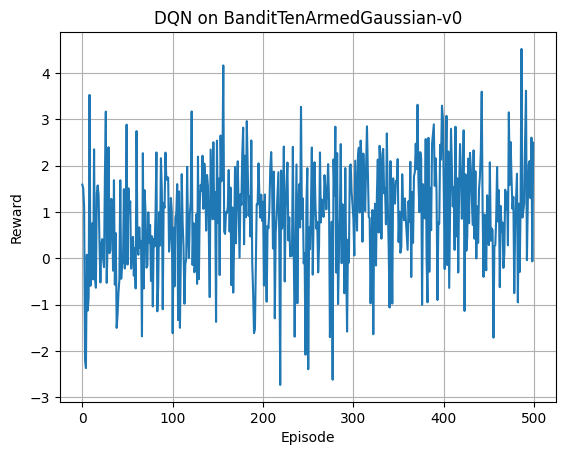

In [15]:

plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN on BanditTenArmedGaussian-v0')
plt.grid(True)
plt.show()
